In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = "../data/processed/cleaned_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Original dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Original dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
columns_to_drop = ["UDI", "Product ID"]

existing_columns = [
    column for column in columns_to_drop
    if column in df.columns
]

df = df.drop(columns=existing_columns)

print("Removed columns:", existing_columns)
print("Updated dataset shape:", df.shape)

print("\nRemaining columns:")
print(df.columns.tolist())

Removed columns: ['UDI', 'Product ID']
Updated dataset shape: (10000, 12)

Remaining columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [4]:
print("Missing values in each column:")
display(df.isnull().sum())

print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values in each column:


Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Total missing values: 0
Duplicate rows: 0


In [5]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.0,0.0,0.0,1.0
OSF,10000.0,0.00980,0.098514,0.0,0.0,0.0,0.0,1.0


Machine failure counts:


Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure percentages:


Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

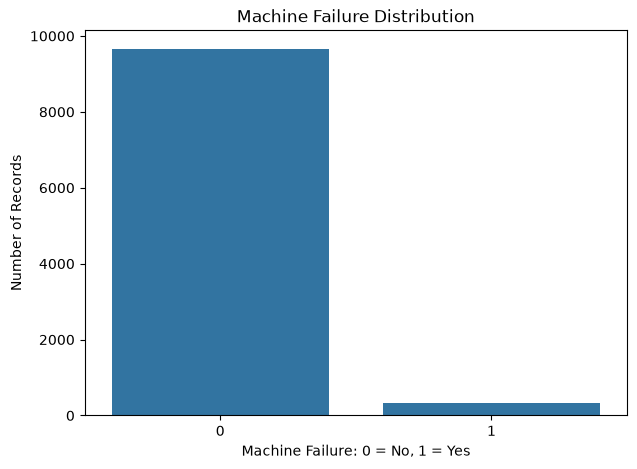

In [6]:
print("Machine failure counts:")
display(df["Machine failure"].value_counts())

print("Machine failure percentages:")
display(
    df["Machine failure"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure: 0 = No, 1 = Yes")
plt.ylabel("Number of Records")
plt.show()

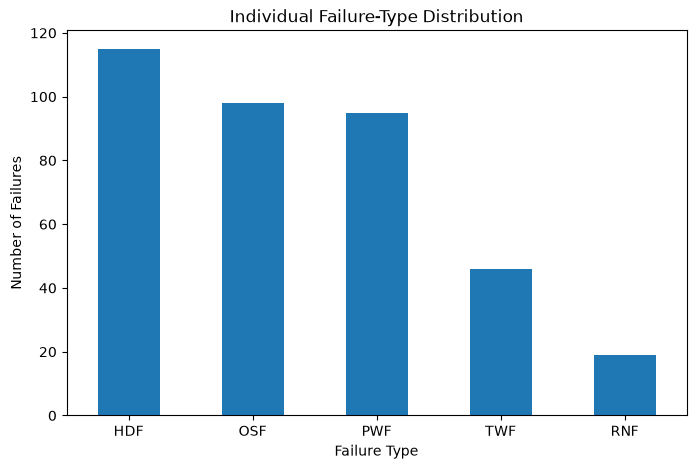

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

In [7]:
failure_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

available_failure_columns = [
    column for column in failure_columns
    if column in df.columns
]

if available_failure_columns:
    failure_counts = (
        df[available_failure_columns]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 5))

    failure_counts.plot(kind="bar")

    plt.title("Individual Failure-Type Distribution")
    plt.xlabel("Failure Type")
    plt.ylabel("Number of Failures")
    plt.xticks(rotation=0)
    plt.show()

    display(failure_counts)
else:
    print("Failure-type columns were not found.")

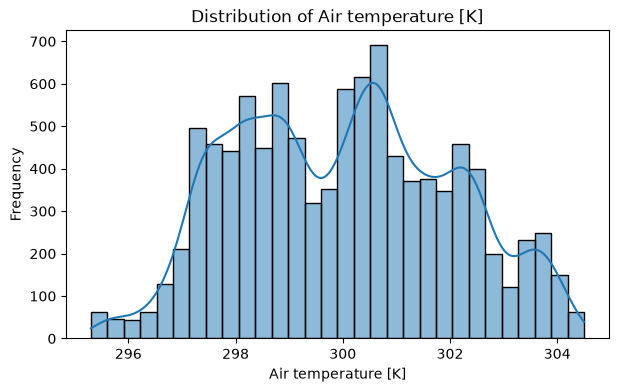

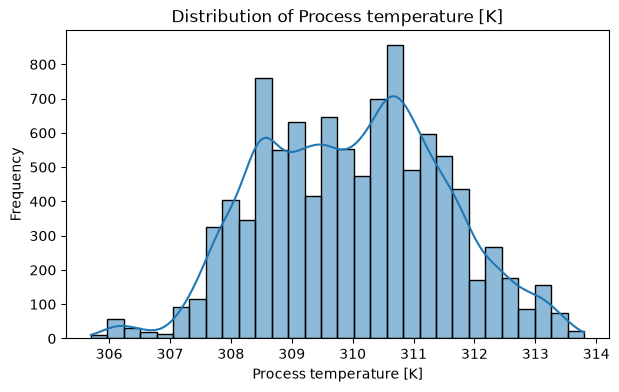

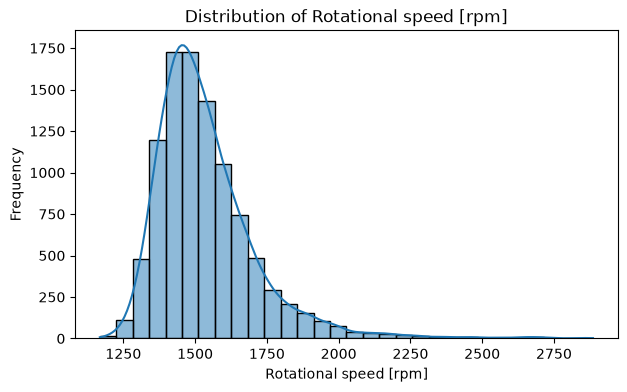

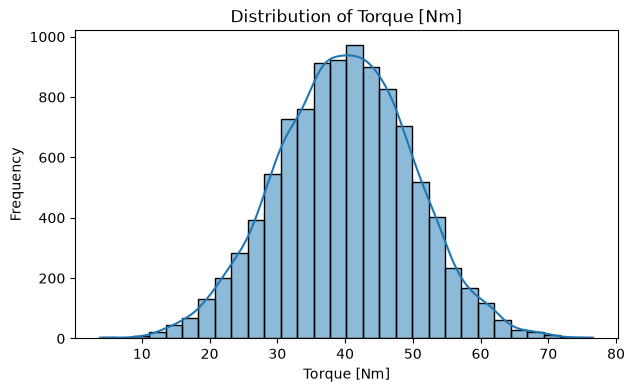

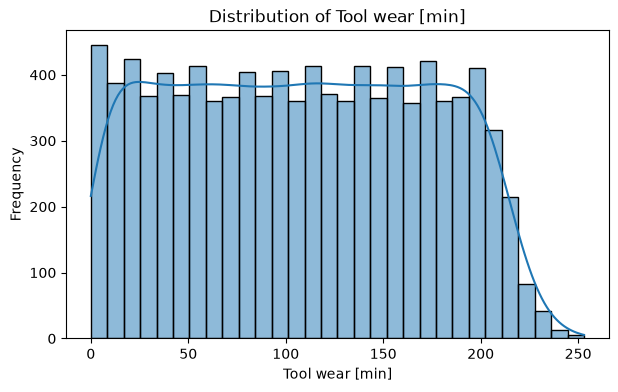

In [8]:
sensor_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

available_sensor_columns = [
    column for column in sensor_columns
    if column in df.columns
]

for column in available_sensor_columns:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

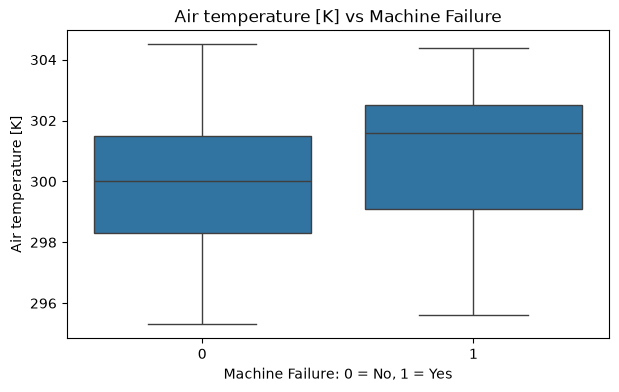

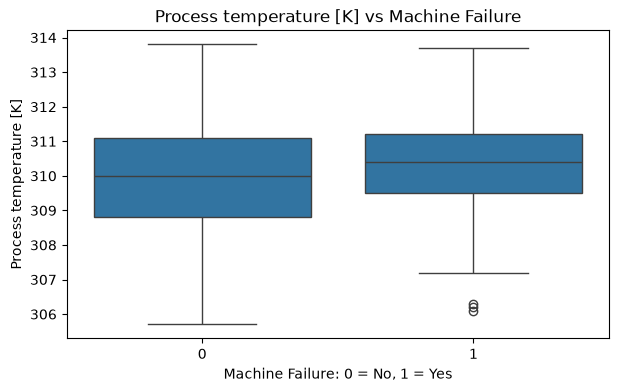

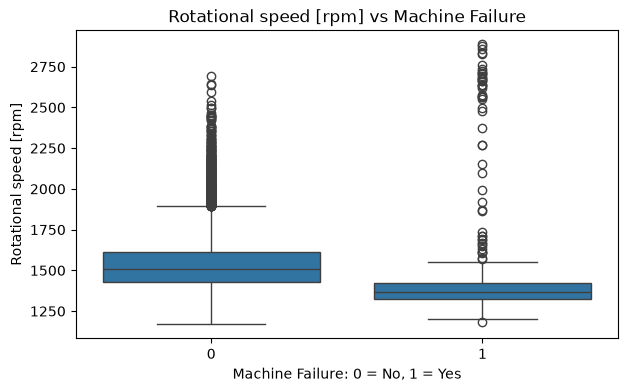

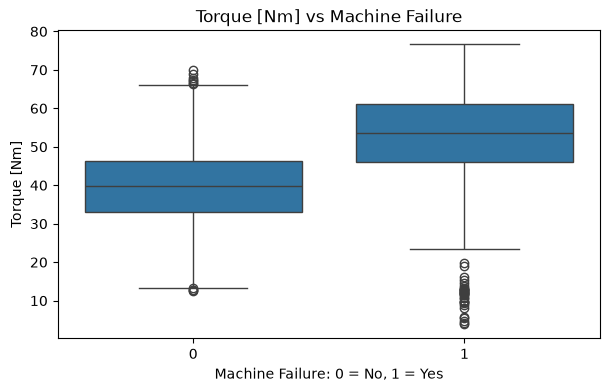

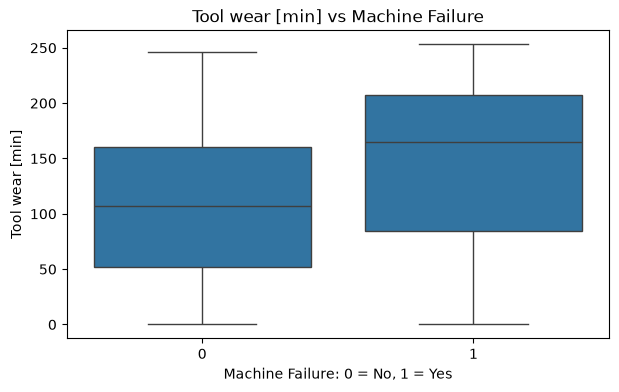

In [9]:
for column in available_sensor_columns:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=column
    )

    plt.title(f"{column} vs Machine Failure")
    plt.xlabel("Machine Failure: 0 = No, 1 = Yes")
    plt.ylabel(column)
    plt.show()

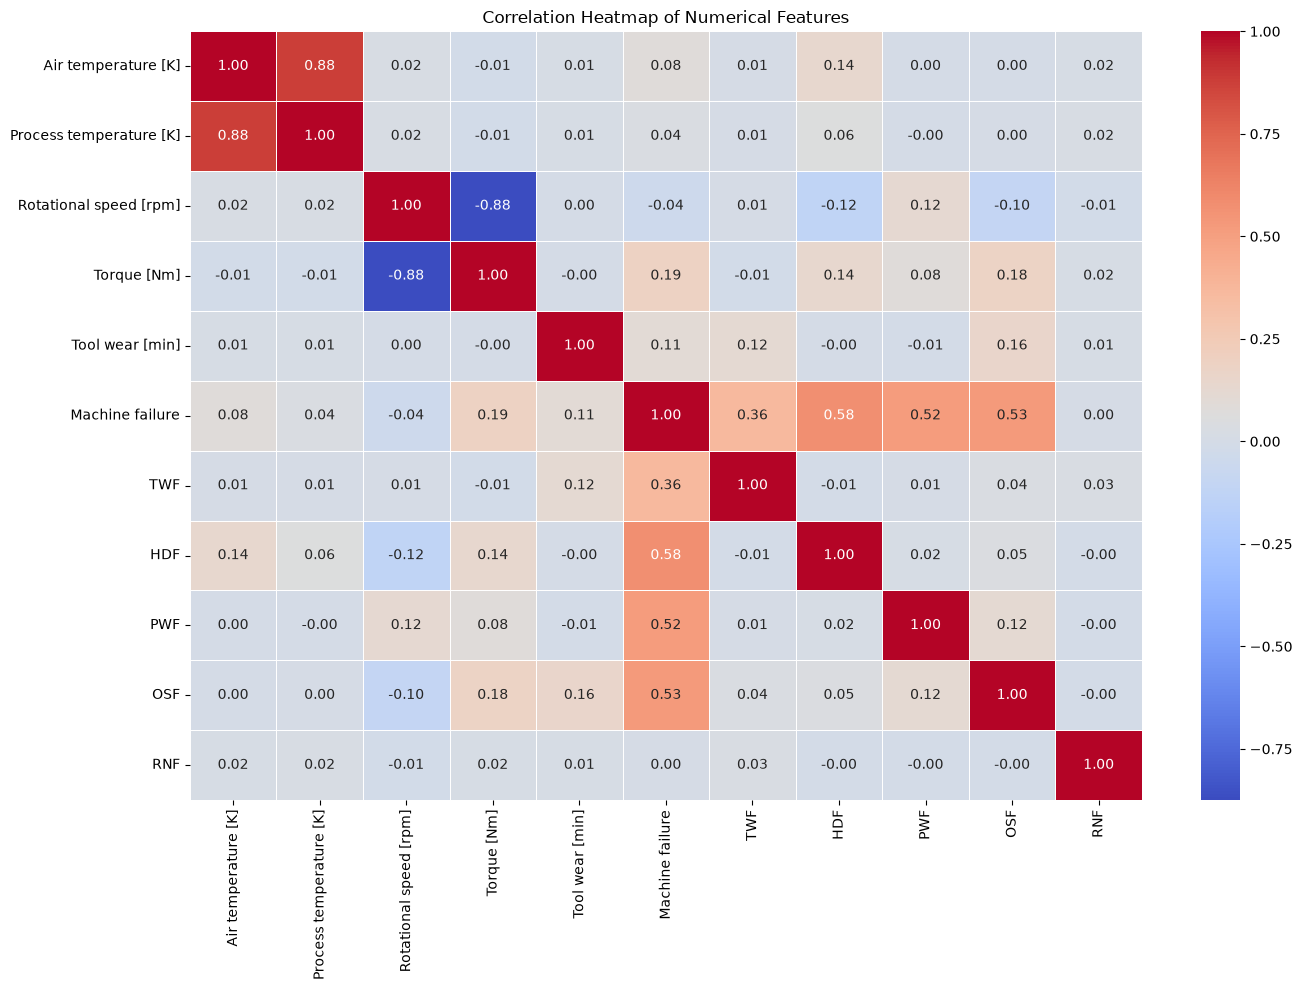

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [11]:
UPDATED_DATA_PATH = "../data/processed/eda_dataset.csv"

df.to_csv(
    UPDATED_DATA_PATH,
    index=False
)

print(f"EDA dataset saved successfully at: {UPDATED_DATA_PATH}")

EDA dataset saved successfully at: ../data/processed/eda_dataset.csv


In [12]:
# Cell 12: Save the EDA summary

eda_summary = {
    "number_of_rows": df.shape[0],
    "number_of_columns": df.shape[1],
    "duplicate_rows": int(df.duplicated().sum()),
    "total_missing_values": int(df.isnull().sum().sum()),
    "machine_failures": int(df["Machine failure"].sum()),
    "failure_rate_percentage": round(
        df["Machine failure"].mean() * 100,
        2
    )
}

eda_summary_df = pd.DataFrame([eda_summary])

SUMMARY_PATH = "../data/processed/eda_summary.csv"

eda_summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

display(eda_summary_df)

print(f"EDA summary saved successfully at: {SUMMARY_PATH}")

,number_of_rows,number_of_columns,duplicate_rows,total_missing_values,machine_failures,failure_rate_percentage
0,10000,12,0,0,339,3.39


EDA summary saved successfully at: ../data/processed/eda_summary.csv
